# Gradient Boosting (GB) on MHAR Feature Set

**Purpose:** This notebook implements the Gradient Boosting (GB) model of Friedman (2001) on the MHAR feature set for the EURO STOXX 50 index, following the tree-based methodology in Christensen, Siggaard, and Veliyev (2023). Gradient Boosting builds a sequence of shallow trees that iteratively fit the remaining forecast errors of the previous ensemble. In the reference paper, GB belongs to the group of models whose hyperparameters are tuned in the validation set, unlike BG and RF which are kept off the shelf. We therefore use the paper's validation grid for tree depth, number of trees, and learning rate, and implement a rolling no-concatenation estimation scheme so the tuning remains separate from the forecasting evaluation.

## 1. Imports

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor


## 2. Data Loading

We again use `MALL.csv` so that the GB forecasts are directly comparable with HAR, BG, RF, and the regularized linear models.

In [2]:
MALL = pd.read_csv("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv")
MALL["Date"] = pd.to_datetime(MALL["Date"])
MALL = MALL.set_index("Date")

print(f"Sample period: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"Number of observations: {len(MALL)}")
display(MALL[["RVD", "RVW", "RVM", "RV_target"]].head())


Sample period: 1999-01-05 to 2020-08-06
Number of observations: 5489


,RVD,RVW,RVM,RV_target
Date,,,,
1999-01-05,0.000078,0.000093,0.000129,0.000058
1999-01-06,0.000058,0.000092,0.000123,0.000139
1999-01-07,0.000139,0.000102,0.000121,0.000108
1999-01-08,0.000108,0.000106,0.000112,0.000166
1999-01-11,0.000166,0.000110,0.000110,0.000115


## 3. Data Split

We retain the 70/10/20 split. Unlike BG and RF, the paper treats GB as a tuned model, so the validation set remains separate and is used to select the boosting hyperparameters before each forecast step.

In [3]:
n = len(MALL)
n_train = int(0.70 * n)
n_val = int(0.10 * n)
n_test = n - n_train - n_val

print(f"Training observations:   {n_train}")
print(f"Validation observations: {n_val}")
print(f"Test observations:       {n_test}")

print(f"Training period:   {MALL.index[0].date()} to {MALL.index[n_train - 1].date()}")
print(f"Validation period: {MALL.index[n_train].date()} to {MALL.index[n_train + n_val - 1].date()}")
print(f"Test period:       {MALL.index[n_train + n_val].date()} to {MALL.index[-1].date()}")


Training observations:   3842
Validation observations: 548
Test observations:       1099
Training period:   1999-01-05 to 2014-02-26
Validation period: 2014-02-27 to 2016-04-20
Test period:       2016-04-21 to 2020-08-06


## 4. Feature Set Construction and Standardization

The paper standardizes all inputs before estimation, so we keep the same preprocessing here. The target stays in levels so the resulting MSE is directly comparable with the benchmark model notebooks.

In [4]:
y = MALL["RV_target"].values
X_MHAR = MALL[["RVD", "RVW", "RVM"]].values

X_train = X_MHAR[:n_train]
X_val = X_MHAR[n_train:n_train + n_val]
X_test = X_MHAR[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std = np.where(X_std == 0, 1.0, X_std)
X_scaled = (X_MHAR - X_mean) / X_std

print("Feature set: RVD, RVW, RVM")
print(f"\nFull dataset:   X={X_scaled.shape}, y={y.shape}")
print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape}")
print("\nStandardization check on training sample:")
print(f"  Means: {X_scaled[:n_train].mean(axis=0).round(6)}")
print(f"  Std:   {X_scaled[:n_train].std(axis=0).round(6)}")


Feature set: RVD, RVW, RVM

Full dataset:   X=(5489, 3), y=(5489,)
Training set:   X=(3842, 3), y=(3842,)
Validation set: X=(548, 3), y=(548,)
Test set:       X=(1099, 3), y=(1099,)

Standardization check on training sample:
  Means: [-0.  0. -0.]
  Std:   [1. 1. 1.]


## 5. Gradient Boosting Hyperparameter Grid

Appendix A.4 of the paper tunes three GB hyperparameters in the validation set: tree depth in `{1, 2}`, number of trees in `{50, 100, ..., 500}`, and learning rate in `{0.01, 0.1}`. To make a full run feasible today, exploratory mode uses a reduced grid and then fixes the best-performing parameter combination from the initial validation exercise for the rolling forecast stage. Setting `exploratory_mode = False` restores the paper-faithful rolling re-tuning setup.

In [5]:
exploratory_mode = True

if exploratory_mode:
    depth_grid = [1, 2]
    n_estimators_grid = [50, 100, 150, 200]
    learning_rate_grid = [0.01, 0.1]
else:
    depth_grid = [1, 2]
    n_estimators_grid = list(range(50, 501, 50))
    learning_rate_grid = [0.01, 0.1]

grid_records = []
best_mse = np.inf
best_params_initial = None
for depth in depth_grid:
    for n_estimators in n_estimators_grid:
        for learning_rate in learning_rate_grid:
            model = GradientBoostingRegressor(
                max_depth=depth,
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                random_state=42
            )
            model.fit(X_scaled[:n_train], y_train)
            y_pred = model.predict(X_scaled[n_train:n_train + n_val])
            mse = np.mean((y_val - y_pred) ** 2)
            grid_records.append({
                "depth": depth,
                "n_estimators": n_estimators,
                "learning_rate": learning_rate,
                "val_mse": mse
            })
            if mse < best_mse:
                best_mse = mse
                best_params_initial = {
                    "depth": depth,
                    "n_estimators": n_estimators,
                    "learning_rate": learning_rate
                }

mode_label = "Exploratory" if exploratory_mode else "Paper-faithful"
print(f"Execution mode: {mode_label}")
print(f"Depth grid: {depth_grid}")
print(f"Tree grid:  {n_estimators_grid}")
print(f"LR grid:    {learning_rate_grid}")
print(f"Best initial validation parameters: {best_params_initial}")
print(f"Best initial validation MSE: {best_mse:.6e}")

grid_results = pd.DataFrame(grid_records).sort_values("val_mse")
display(grid_results.head(10))


Execution mode: Exploratory
Depth grid: [1, 2]
Tree grid:  [50, 100, 150, 200]
LR grid:    [0.01, 0.1]
Best initial validation parameters: {'depth': 2, 'n_estimators': 150, 'learning_rate': 0.01}
Best initial validation MSE: 1.785716e-08


,depth,n_estimators,learning_rate,val_mse
12,2,150,0.01,1.785716e-08
10,2,100,0.01,1.799895e-08
14,2,200,0.01,1.801021e-08
1,1,50,0.10,1.850801e-08
7,1,200,0.10,1.857367e-08
3,1,100,0.10,1.857749e-08
5,1,150,0.10,1.858826e-08
6,1,200,0.01,1.889071e-08
4,1,150,0.01,1.933222e-08
8,2,50,0.01,1.939648e-08


## 6. Rolling Window Tuning, Estimation, and Forecasting

Following the paper, GB is treated as a tuned model. In paper-faithful mode, the notebook re-tunes the hyperparameters inside each rolling window using the validation block. In exploratory mode, we still select the GB specification by validation MSE, but we do so once in the initial split and then keep that best-performing configuration fixed during the rolling forecast loop. This preserves the model-selection logic while making a full run feasible today.

In [6]:
window_size = n_train + n_val

forecasts_GB = []
dates_test = []
best_params_path = []

start_time = time.time()

for i in range(n_test):
    X_window = X_scaled[i:i + window_size]
    y_window = y[i:i + window_size]

    if exploratory_mode:
        best_params = best_params_initial.copy()
        best_model = GradientBoostingRegressor(
            max_depth=best_params["depth"],
            n_estimators=best_params["n_estimators"],
            learning_rate=best_params["learning_rate"],
            random_state=42
        )
        best_model.fit(X_window, y_window)
    else:
        X_win_train = X_window[:-n_val]
        X_win_val = X_window[-n_val:]
        y_win_train = y_window[:-n_val]
        y_win_val = y_window[-n_val:]

        best_mse_window = np.inf
        best_params = None
        best_model = None

        for depth in depth_grid:
            for n_estimators in n_estimators_grid:
                for learning_rate in learning_rate_grid:
                    model = GradientBoostingRegressor(
                        max_depth=depth,
                        n_estimators=n_estimators,
                        learning_rate=learning_rate,
                        random_state=42
                    )
                    model.fit(X_win_train, y_win_train)
                    y_pred = model.predict(X_win_val)
                    mse = np.mean((y_win_val - y_pred) ** 2)
                    if mse < best_mse_window:
                        best_mse_window = mse
                        best_params = {
                            "depth": depth,
                            "n_estimators": n_estimators,
                            "learning_rate": learning_rate
                        }
                        best_model = model

    X_forecast = X_scaled[i + window_size].reshape(1, -1)
    forecast = best_model.predict(X_forecast)[0]
    forecast = max(forecast, y_window.min())

    forecasts_GB.append(forecast)
    dates_test.append(MALL.index[i + window_size])
    best_params_path.append(best_params)

    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i + 1:4d}/{n_test} | Date: {MALL.index[i + window_size].date()} | Best params: {best_params} | Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print()
print(f"Total estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_GB)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")
display(pd.DataFrame(best_params_path).value_counts().rename("Count").reset_index())


  Day  100/1099 | Date: 2016-09-08 | Best params: {'depth': 2, 'n_estimators': 150, 'learning_rate': 0.01} | Elapsed: 0.6 min


  Day  200/1099 | Date: 2017-01-27 | Best params: {'depth': 2, 'n_estimators': 150, 'learning_rate': 0.01} | Elapsed: 1.2 min


  Day  300/1099 | Date: 2017-06-21 | Best params: {'depth': 2, 'n_estimators': 150, 'learning_rate': 0.01} | Elapsed: 1.7 min


  Day  400/1099 | Date: 2017-11-08 | Best params: {'depth': 2, 'n_estimators': 150, 'learning_rate': 0.01} | Elapsed: 2.3 min


  Day  500/1099 | Date: 2018-04-04 | Best params: {'depth': 2, 'n_estimators': 150, 'learning_rate': 0.01} | Elapsed: 2.9 min


...

  Day  800/1099 | Date: 2019-06-06 | Best params: {'depth': 2, 'n_estimators': 150, 'learning_rate': 0.01} | Elapsed: 4.6 min


  Day  900/1099 | Date: 2019-10-24 | Best params: {'depth': 2, 'n_estimators': 150, 'learning_rate': 0.01} | Elapsed: 5.2 min


  Day 1000/1099 | Date: 2020-03-17 | Best params: {'depth': 2, 'n_estimators': 150, 'learning_rate': 0.01} | Elapsed: 5.7 min



Total estimation time: 6.3 minutes
Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06


,depth,n_estimators,learning_rate,Count
0,2,150,0.01,1099


## 7. Save Forecasts

We save the GB forecasts and summary metrics in the same format as the other MHAR notebooks so they can be used in later comparison exercises.

In [7]:
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
os.makedirs(forecast_path, exist_ok=True)

test_dates = MALL.index[n_train + n_val:]
results_GB = pd.DataFrame({"RV_actual": y_test, "RV_forecast": forecasts_GB}, index=test_dates)
errors_GB = results_GB["RV_actual"] - results_GB["RV_forecast"]
mse_GB = np.mean(errors_GB ** 2)

results_name = "forecasts_GB_exploratory.csv" if exploratory_mode else "forecasts_GB.csv"
summary_name = "mse_summary_GB_exploratory.csv" if exploratory_mode else "mse_summary_GB.csv"

results_GB.to_csv(os.path.join(forecast_path, results_name))
mse_summary_GB = pd.DataFrame({
    "Model": ["GB_exploratory" if exploratory_mode else "GB"],
    "MSE": [mse_GB],
    "RMSE": [np.sqrt(mse_GB)],
    "MAE": [errors_GB.abs().mean()],
    "Mean_Error": [errors_GB.mean()]
}).set_index("Model")
mse_summary_GB.to_csv(os.path.join(forecast_path, summary_name))

print(f"Forecasts saved to: {forecast_path}")
print(f"Rows saved: {len(results_GB)}")
print(f"Forecast file: {results_name}")
print(f"Summary file:  {summary_name}")
print(f"Gradient Boosting test-set MSE: {mse_GB:.6e}")


Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR
Rows saved: 1099
Forecast file: forecasts_GB_exploratory.csv
Summary file:  mse_summary_GB_exploratory.csv
Gradient Boosting test-set MSE: 2.457358e-08


## 8. Out-of-Sample Performance Evaluation

We compare GB with HAR on the same test period and report the standard level-scale metrics used throughout the thesis notebooks.

In [8]:
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
results_HAR = pd.read_csv(os.path.join(forecast_path, "forecasts_HAR.csv"), index_col=0, parse_dates=True)
mse_HAR = np.mean((results_HAR["RV_actual"] - results_HAR["RV_forecast"]) ** 2)
errors_HAR = results_HAR["RV_actual"] - results_HAR["RV_forecast"]
rel_mse_GB = mse_GB / mse_HAR

print(f"Out-of-sample performance ({test_dates[0].date()} to {test_dates[-1].date()}):")
print(f"\n{'Model':<10} {'MSE':>12} {'RMSE':>12} {'MAE':>12} {'Mean Error':>12} {'Rel. MSE':>10}")
print("-" * 70)
print(f"{'HAR':<10} {mse_HAR:>12.6e} {np.sqrt(mse_HAR):>12.6e} {errors_HAR.abs().mean():>12.6e} {errors_HAR.mean():>12.6e} {1.0:>10.4f}")
print(f"{'GB':<10} {mse_GB:>12.6e} {np.sqrt(mse_GB):>12.6e} {errors_GB.abs().mean():>12.6e} {errors_GB.mean():>12.6e} {rel_mse_GB:>10.4f}")
print("-" * 70)
print(f"\nGB vs HAR: {'outperforms' if rel_mse_GB < 1 else 'underperforms'} by {abs(1 - rel_mse_GB) * 100:.2f}%")


Out-of-sample performance (2016-04-21 to 2020-08-06):

Model               MSE         RMSE          MAE   Mean Error   Rel. MSE
----------------------------------------------------------------------
HAR        2.221336e-08 1.490415e-04 5.592501e-05 -4.057863e-06     1.0000
GB         2.457358e-08 1.567596e-04 7.300480e-05 -2.110713e-05     1.1063
----------------------------------------------------------------------

GB vs HAR: underperforms by 10.63%


## 9. Forecast Visualization

As in the other notebooks, we convert realized variance into annualized volatility before plotting the actual and forecasted series so the graph is directly comparable across models.

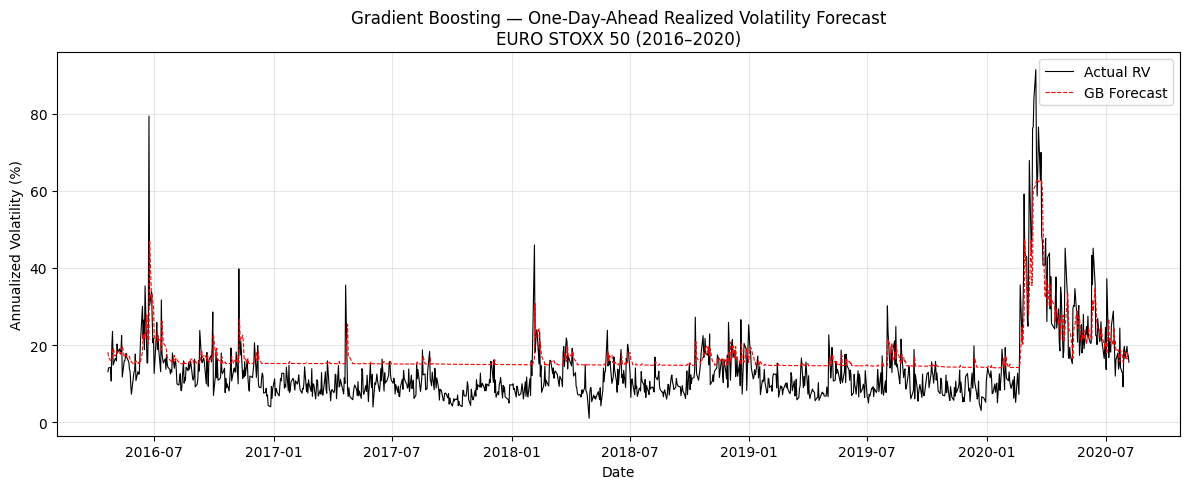


Summary of forecast errors:
Mean error:  -2.110713e-05
RMSE:        1.567596e-04
MAE:         7.300480e-05


In [9]:
results_plot_GB = pd.DataFrame({
    "Actual": np.sqrt(results_GB["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_GB["RV_forecast"] * 252) * 100
}, index=results_GB.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot_GB["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot_GB["Forecast"], label="GB Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("Gradient Boosting — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary of forecast errors:")
print(f"Mean error:  {errors_GB.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_GB):.6e}")
print(f"MAE:         {errors_GB.abs().mean():.6e}")
